# Modern Lakehouse — Complete Medallion Architecture Project

**Platform:** Databricks Free Edition  
**Technologies:** PySpark, Spark SQL, Delta Lake, Databricks

## Project objective

Build a small but production-oriented **Bronze → Silver → Gold** lakehouse with explicit data-quality controls.

```text
Source Data
    ↓
BRONZE
Raw / source-aligned Delta tables
    ↓
SILVER
Standardized + business-key deduplicated + validated + referentially trusted data
    ↓
GOLD
Business-ready analytical datasets
```

### What this notebook demonstrates

- Delta tables and managed tables
- Medallion architecture
- Schema/type standardization
- Data cleaning and normalization
- **Business-key deduplication**
- **Deterministic duplicate selection**
- **Order ID validation before an order can be VALID**
- **Order-item business-key duplicate checks**
- Row-level validation and quarantine
- Referential integrity
- Order-level revenue reconciliation
- PySpark joins and aggregations
- Grain awareness
- Gold business metrics
- SQL validation
- End-to-end reconciliation

> **Portfolio note:** The synthetic source includes stable source-row identifiers so duplicate resolution is deterministic. In a production source, this role would normally be filled by a source-system record ID, ingestion timestamp, or other reliable ordering column.


## 0. Project setup

We use **managed Delta tables** rather than DBFS paths. This makes the notebook suitable for Databricks Free Edition environments where public DBFS root access may be disabled.

For repeatable practice, we also remove the previous project tables at the beginning. This avoids stale Delta metadata/schema conflicts when rerunning the notebook after changing a table definition.


In [0]:
# Project configuration

CATALOG = "workspace"
SCHEMA = "medallion_project"

spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")

print(f"Project schema: {CATALOG}.{SCHEMA}")


Project schema: workspace.medallion_project


In [0]:
# Core PySpark imports used throughout the notebook.
# Databricks provides Spark itself, but F and Window must be imported explicitly.
from pyspark.sql import functions as F
from pyspark.sql.window import Window

print("PySpark functions and Window imported successfully.")


PySpark functions and Window imported successfully.


In [0]:
# Reset project tables for a clean, repeatable run.
# Safe for this learning project because all data is synthetic.

tables_to_drop = [
    "bronze_customers",
    "bronze_products",
    "bronze_orders",
    "bronze_order_items",
    "silver_customers",
    "silver_products",
    "silver_orders",
    "silver_order_items",
    "quarantine_orders",
    "quarantine_duplicate_customers",
    "quarantine_duplicate_orders",
    "quarantine_products",
    "quarantine_order_items",
    "quarantine_duplicate_order_items",
    "quarantine_orphan_order_items",
    "quarantine_order_reconciliation",
    "gold_customer_sales",
    "gold_product_sales",
    "gold_daily_sales",
    "gold_sales_summary"
]

for table in tables_to_drop:
    spark.sql(f"DROP TABLE IF EXISTS {CATALOG}.{SCHEMA}.{table}")

print("Project reset complete.")


Project reset complete.


In [0]:
%sql
SHOW TABLES IN workspace.medallion_project;


database,tableName,isTemporary


# 1. Source data

We create four small source datasets:

1. **Customers** — customer master data
2. **Products** — product master data
3. **Orders** — order-level transactions
4. **Order items** — item-level transaction detail

The source data intentionally contains:

- duplicate customer
- inconsistent city casing
- missing city
- duplicate order with the same business key
- order with a missing customer
- order with a missing `order_id`
- negative order amount
- duplicate order-item business key
- order item belonging to a rejected order

### Declared source grains

| Dataset | Intended source grain |
|---|---|
| Customers | 1 row per `customer_id` |
| Products | 1 row per `product_id` |
| Orders | 1 row per `order_id` |
| Order items | 1 row per (`order_id`, `product_id`) |

For this synthetic project, **`(order_id, product_id)` is the business key of an order-item row**. Therefore, repeated rows for the same order/product combination are treated as duplicates, not separate legitimate lines.

### Revenue assumption

For this project we explicitly assume:

```text
order_amount = SUM(quantity × product.price) for all valid items in the order
```

This is a **business rule for the synthetic dataset**, not a universal e-commerce rule. A real system may have discounts, tax, shipping, refunds, or a separate order-total source that changes this relationship.


In [0]:
# -----------------------------
# Customers
# -----------------------------
# source_row_id is stable synthetic source metadata for deterministic
# business-key deduplication.

customers_data = [
    (1, 101, "Bharath", "Chennai", "2025-01-10"),
    (2, 102, "Ravi", "chennai", "2025-01-15"),
    (3, 103, "Arun", "Bangalore", "2025-02-01"),
    (4, 104, "Priya", "CHENNAI", "2025-02-10"),
    (5, 105, "Kumar", None, "2025-02-15"),
    (6, 101, "Bharath", "Chennai", "2025-01-10")  # intentional duplicate
]

customers_df = spark.createDataFrame(
    customers_data,
    ["source_row_id", "customer_id", "name", "city", "registration_date"]
)

display(customers_df)


source_row_id,customer_id,name,city,registration_date
1,101,Bharath,Chennai,2025-01-10
2,102,Ravi,chennai,2025-01-15
3,103,Arun,Bangalore,2025-02-01
4,104,Priya,CHENNAI,2025-02-10
5,105,Kumar,null,2025-02-15
6,101,Bharath,Chennai,2025-01-10


In [0]:
# -----------------------------
# Products
# -----------------------------

products_data = [
    (201, "Laptop", "Electronics", 75000.0),
    (202, "Mouse", "Accessories", 1200.0),
    (203, "Keyboard", "Accessories", 2500.0),
    (204, "Monitor", "Electronics", 18000.0),
    (205, "Headphones", "Accessories", 3500.0)
]

products_df = spark.createDataFrame(
    products_data,
    ["product_id", "product_name", "category", "price"]
)

display(products_df)


product_id,product_name,category,price
201,Laptop,Electronics,75000.0
202,Mouse,Accessories,1200.0
203,Keyboard,Accessories,2500.0
204,Monitor,Electronics,18000.0
205,Headphones,Accessories,3500.0


In [0]:
# -----------------------------
# Orders
# -----------------------------
# source_row_id is a stable synthetic source sequence used only
# to make duplicate resolution deterministic.

orders_data = [
    (1, 1001, 101, "2025-03-01", 76200.0),
    (2, 1002, 102, "2025-03-02", 1200.0),
    (3, 1003, 103, "2025-03-03", 20500.0),
    (4, 1004, 104, "2025-03-04", 3500.0),
    (5, 1005, 105, "2025-03-05", 18000.0),
    (6, 1005, 105, "2025-03-05", 18000.0),  # intentional business-key duplicate
    (7, 1006, None, "2025-03-06", 2500.0),  # invalid customer
    (8, 1007, 101, "2025-03-07", -500.0),   # invalid amount
    (9, None, 101, "2025-03-08", 2500.0)    # invalid order_id
]

orders_df = spark.createDataFrame(
    orders_data,
    ["source_row_id", "order_id", "customer_id", "order_date", "order_amount"]
)

display(orders_df)


source_row_id,order_id,customer_id,order_date,order_amount
1,1001,101,2025-03-01,76200.0
2,1002,102,2025-03-02,1200.0
3,1003,103,2025-03-03,20500.0
4,1004,104,2025-03-04,3500.0
5,1005,105,2025-03-05,18000.0
6,1005,105,2025-03-05,18000.0
7,1006,null,2025-03-06,2500.0
8,1007,101,2025-03-07,-500.0
9,null,101,2025-03-08,2500.0


In [0]:
# -----------------------------
# Order items
# -----------------------------
# source_row_id provides a deterministic tie-breaker for duplicate
# business keys. The intended grain is one row per (order_id, product_id).

order_items_data = [
    (1, 1001, 201, 1),
    (2, 1001, 202, 1),
    (3, 1002, 202, 1),
    (4, 1003, 203, 1),
    (5, 1003, 204, 1),
    (6, 1004, 205, 1),
    (7, 1005, 204, 1),
    (8, 1005, 204, 1),  # intentional business-key duplicate
    (9, 1006, 203, 1)   # orphan after order 1006 is rejected
]

order_items_df = spark.createDataFrame(
    order_items_data,
    ["source_row_id", "order_id", "product_id", "quantity"]
)

display(order_items_df)


source_row_id,order_id,product_id,quantity
1,1001,201,1
2,1001,202,1
3,1002,202,1
4,1003,203,1
5,1003,204,1
6,1004,205,1
7,1005,204,1
8,1005,204,1
9,1006,203,1


## Source-data checks

Before writing anything, confirm the expected source counts.

Expected:

- Customers = 6
- Products = 5
- Orders = 9
- Order items = 9


In [0]:
source_counts = {
    "customers": customers_df.count(),
    "products": products_df.count(),
    "orders": orders_df.count(),
    "order_items": order_items_df.count()
}

print(source_counts)

assert source_counts["customers"] == 6
assert source_counts["products"] == 5
assert source_counts["orders"] == 9
assert source_counts["order_items"] == 9

print("SOURCE CHECK: PASS")


{'customers': 6, 'products': 5, 'orders': 9, 'order_items': 9}
SOURCE CHECK: PASS


# 2. BRONZE — Raw Delta Layer

## Purpose

Bronze should preserve the source data as faithfully as possible.

We are **not** cleaning the data here.

```text
Source
  ↓
Bronze
  └── Preserve what arrived
```

The Bronze layer gives us a recoverable source-aligned representation that downstream layers can process repeatedly.


In [0]:
bronze_schema = f"{CATALOG}.{SCHEMA}"

customers_df.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.bronze_customers"
)

products_df.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.bronze_products"
)

orders_df.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.bronze_orders"
)

order_items_df.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.bronze_order_items"
)

print("Bronze Delta tables created.")


Bronze Delta tables created.


In [0]:
%sql
SHOW TABLES IN workspace.medallion_project;


database,tableName,isTemporary
medallion_project,bronze_customers,false
medallion_project,bronze_order_items,false
medallion_project,bronze_orders,false
medallion_project,bronze_products,false


## Bronze validation

Bronze should preserve the original source counts, including intentional bad records and duplicates.

The technical `source_row_id` columns are retained as source metadata so downstream duplicate selection can be deterministic and auditable.


In [0]:
bronze_counts = {
    "customers": spark.table(f"{bronze_schema}.bronze_customers").count(),
    "products": spark.table(f"{bronze_schema}.bronze_products").count(),
    "orders": spark.table(f"{bronze_schema}.bronze_orders").count(),
    "order_items": spark.table(f"{bronze_schema}.bronze_order_items").count()
}

print(bronze_counts)

assert bronze_counts == source_counts
print("BRONZE ROW-COUNT CHECK: PASS")


{'customers': 6, 'products': 5, 'orders': 9, 'order_items': 9}
BRONZE ROW-COUNT CHECK: PASS


In [0]:
%sql
SELECT * FROM workspace.medallion_project.bronze_customers;


source_row_id,customer_id,name,city,registration_date
1,101,Bharath,Chennai,2025-01-10
2,102,Ravi,chennai,2025-01-15
3,103,Arun,Bangalore,2025-02-01
4,104,Priya,CHENNAI,2025-02-10
5,105,Kumar,null,2025-02-15
6,101,Bharath,Chennai,2025-01-10


In [0]:
%sql
SELECT * FROM workspace.medallion_project.bronze_orders ORDER BY order_id;


source_row_id,order_id,customer_id,order_date,order_amount
9,null,101,2025-03-08,2500.0
1,1001,101,2025-03-01,76200.0
2,1002,102,2025-03-02,1200.0
3,1003,103,2025-03-03,20500.0
4,1004,104,2025-03-04,3500.0
5,1005,105,2025-03-05,18000.0
6,1005,105,2025-03-05,18000.0
7,1006,null,2025-03-06,2500.0
8,1007,101,2025-03-07,-500.0


# 3. SILVER — Clean, Validated and Trusted Layer

Silver is where we progressively refine Bronze data.

We will apply:

1. Type standardization
2. Text standardization
3. Deduplication
4. Row-level validation
5. Quarantine
6. Referential-integrity checks
7. Final quality validation

```text
BRONZE
   ↓
Standardize
   ↓
Deduplicate
   ↓
Validate
   ↓
┌───────────────┐
│ VALID         │ → SILVER
│ INVALID       │ → QUARANTINE
└───────────────┘
```


## 3.1 Silver Customers

Rules:

- `customer_id` must exist
- `registration_date` becomes a real date
- city whitespace/casing is standardized
- missing city is represented as `Unknown`
- business-key duplicates are identified using `customer_id`
- for duplicate customers, the deterministic winner is the row with the greatest `registration_date`, then greatest `source_row_id`


In [0]:
bronze_customers = spark.table(
    f"{bronze_schema}.bronze_customers"
)

print("Bronze customer schema:")
bronze_customers.printSchema()

customers_silver = (
    bronze_customers
    .withColumn(
        "registration_date",
        F.to_date("registration_date", "yyyy-MM-dd")
    )
    .withColumn(
        "city",
        F.initcap(F.trim(F.col("city")))
    )
    .withColumn(
        "city",
        F.coalesce(F.col("city"), F.lit("Unknown"))
    )
)

display(customers_silver)


Bronze customer schema:
root
 |-- source_row_id: long (nullable = true)
 |-- customer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- registration_date: string (nullable = true)



source_row_id,customer_id,name,city,registration_date
1,101,Bharath,Chennai,2025-01-10
2,102,Ravi,Chennai,2025-01-15
3,103,Arun,Bangalore,2025-02-01
4,104,Priya,Chennai,2025-02-10
5,105,Kumar,Unknown,2025-02-15
6,101,Bharath,Chennai,2025-01-10


In [0]:
# Check date conversion
invalid_dates = customers_silver.filter(
    F.col("registration_date").isNull()
)

print("Invalid registration dates:", invalid_dates.count())
assert invalid_dates.count() == 0

# Check city standardization
display(
    customers_silver.select("customer_id", "city")
)


Invalid registration dates: 0


customer_id,city
101,Chennai
102,Chennai
103,Bangalore
104,Chennai
105,Unknown
101,Chennai


In [0]:
# Business-key duplicate check before deduplication.
# The customer grain is one row per customer_id.

customer_duplicate_groups = (
    customers_silver
    .groupBy("customer_id")
    .count()
    .filter(F.col("count") > 1)
)

display(customer_duplicate_groups)

print("Duplicate customer business-key groups:", customer_duplicate_groups.count())
assert customer_duplicate_groups.count() == 1


customer_id,count
101,2


Duplicate customer business-key groups: 1


In [0]:
# Deterministic business-key deduplication.
# Prefer the most recent registration date; source_row_id is the
# deterministic tie-breaker for otherwise equivalent records.

customer_window = (
    Window
    .partitionBy("customer_id")
    .orderBy(
        F.col("registration_date").desc_nulls_last(),
        F.col("source_row_id").desc()
    )
)

customers_ranked = customers_silver.withColumn(
    "_dedup_rank",
    F.row_number().over(customer_window)
)

duplicate_customers_quarantine = (
    customers_ranked
    .filter(F.col("_dedup_rank") > 1)
    .drop("_dedup_rank")
)

customers_silver = (
    customers_ranked
    .filter(F.col("_dedup_rank") == 1)
    .drop("_dedup_rank")
)

print("Customers after business-key deduplication:", customers_silver.count())
print("Duplicate customer rows quarantined:", duplicate_customers_quarantine.count())

assert customers_silver.count() == 5
assert duplicate_customers_quarantine.count() == 1


Customers after business-key deduplication: 5
Duplicate customer rows quarantined: 1


In [0]:
# Row-level validation

invalid_customers = customers_silver.filter(
    F.col("customer_id").isNull() |
    F.col("name").isNull() |
    F.col("registration_date").isNull()
)

print("Invalid customer rows:", invalid_customers.count())
assert invalid_customers.count() == 0

valid_customers = customers_silver

valid_customers.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.silver_customers"
)

duplicate_customers_quarantine.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_duplicate_customers"
)

display(valid_customers)


Invalid customer rows: 0


source_row_id,customer_id,name,city,registration_date
6,101,Bharath,Chennai,2025-01-10
2,102,Ravi,Chennai,2025-01-15
3,103,Arun,Bangalore,2025-02-01
4,104,Priya,Chennai,2025-02-10
5,105,Kumar,Unknown,2025-02-15


In [0]:
%sql
SELECT COUNT(*) AS silver_customers
FROM workspace.medallion_project.silver_customers;


silver_customers
5


## 3.2 Silver Orders

Rules:

1. `order_date` becomes a date.
2. `order_id` is the business identifier.
3. Business-key duplicates are identified by `order_id`.
4. Duplicate orders are resolved **deterministically** before final validation.
5. `order_id` must be non-null before a row can ever receive `VALID`.
6. `customer_id` cannot be null.
7. `order_amount` must be positive.
8. Invalid orders are quarantined rather than silently deleted.

### Deterministic duplicate rule

For repeated `order_id` values, keep the record with:

1. the most complete row,
2. the latest valid `order_date`,
3. the greatest `source_row_id` as the stable final tie-breaker.

The winning row and discarded duplicate rows are separated explicitly.


In [0]:
orders_bronze = spark.table(
    f"{bronze_schema}.bronze_orders"
)

orders_silver = (
    orders_bronze
    .withColumn(
        "order_date",
        F.to_date("order_date", "yyyy-MM-dd")
    )
    .withColumn(
        "_completeness_score",
        F.when(F.col("order_id").isNotNull(), 1).otherwise(0)
        + F.when(F.col("customer_id").isNotNull(), 1).otherwise(0)
        + F.when(F.col("order_date").isNotNull(), 1).otherwise(0)
        + F.when(F.col("order_amount").isNotNull(), 1).otherwise(0)
    )
)

orders_silver.printSchema()
display(orders_silver)


root
 |-- source_row_id: long (nullable = true)
 |-- order_id: long (nullable = true)
 |-- customer_id: long (nullable = true)
 |-- order_date: date (nullable = true)
 |-- order_amount: double (nullable = true)
 |-- _completeness_score: integer (nullable = false)



source_row_id,order_id,customer_id,order_date,order_amount,_completeness_score
1,1001,101,2025-03-01,76200.0,4
2,1002,102,2025-03-02,1200.0,4
3,1003,103,2025-03-03,20500.0,4
4,1004,104,2025-03-04,3500.0,4
5,1005,105,2025-03-05,18000.0,4
6,1005,105,2025-03-05,18000.0,4
7,1006,null,2025-03-06,2500.0,3
8,1007,101,2025-03-07,-500.0,4
9,null,101,2025-03-08,2500.0,3


In [0]:
# Business-key duplicate check.
# The order grain is one row per order_id.

duplicate_order_groups = (
    orders_silver
    .groupBy("order_id")
    .count()
    .filter(
        F.col("order_id").isNotNull() &
        (F.col("count") > 1)
    )
)

display(duplicate_order_groups)

print("Duplicate order business-key groups:", duplicate_order_groups.count())
assert duplicate_order_groups.count() == 1


order_id,count
1005,2


Duplicate order business-key groups: 1


In [0]:
# Deterministic business-key deduplication.
# source_row_id is the stable final tie-breaker for exact duplicates.

order_window = (
    Window
    .partitionBy("order_id")
    .orderBy(
        F.col("_completeness_score").desc(),
        F.col("order_date").desc_nulls_last(),
        F.col("order_amount").desc_nulls_last(),
        F.col("customer_id").desc_nulls_last(),
        F.col("source_row_id").desc()
    )
)

orders_ranked = orders_silver.withColumn(
    "_dedup_rank",
    F.when(
        F.col("order_id").isNotNull(),
        F.row_number().over(order_window)
    )
)

duplicate_orders_quarantine = (
    orders_ranked
    .filter(F.col("_dedup_rank") > 1)
    .drop("_dedup_rank", "_completeness_score")
)

orders_silver = (
    orders_ranked
    .filter(
        F.col("order_id").isNull() |
        (F.col("_dedup_rank") == 1)
    )
    .drop("_dedup_rank", "_completeness_score")
)

print("Orders after business-key deduplication:", orders_silver.count())
print("Duplicate order rows quarantined:", duplicate_orders_quarantine.count())

assert orders_silver.count() == 8
assert duplicate_orders_quarantine.count() == 1


Orders after business-key deduplication: 8
Duplicate order rows quarantined: 1


In [0]:
# IMPORTANT: order_id is validated BEFORE VALID can be assigned.
# An order with a missing business key can never become a valid order.

orders_silver = orders_silver.withColumn(
    "validation_status",
    F.when(
        F.col("order_id").isNull(),
        F.lit("INVALID_ORDER_ID")
    )
    .when(
        F.col("customer_id").isNull(),
        F.lit("INVALID_CUSTOMER")
    )
    .when(
        F.col("order_date").isNull(),
        F.lit("INVALID_DATE")
    )
    .when(
        F.col("order_amount").isNull(),
        F.lit("INVALID_AMOUNT")
    )
    .when(
        F.col("order_amount") <= 0,
        F.lit("INVALID_AMOUNT")
    )
    .otherwise(F.lit("VALID"))
)

display(orders_silver)


source_row_id,order_id,customer_id,order_date,order_amount,validation_status
9,null,101,2025-03-08,2500.0,INVALID_ORDER_ID
1,1001,101,2025-03-01,76200.0,VALID
2,1002,102,2025-03-02,1200.0,VALID
3,1003,103,2025-03-03,20500.0,VALID
4,1004,104,2025-03-04,3500.0,VALID
6,1005,105,2025-03-05,18000.0,VALID
7,1006,null,2025-03-06,2500.0,INVALID_CUSTOMER
8,1007,101,2025-03-07,-500.0,INVALID_AMOUNT


In [0]:
valid_orders = (
    orders_silver
    .filter(F.col("validation_status") == "VALID")
    .drop("validation_status")
)

quarantine_orders = (
    orders_silver
    .filter(F.col("validation_status") != "VALID")
)

print("Valid orders:", valid_orders.count())
print("Quarantined orders:", quarantine_orders.count())

assert valid_orders.count() == 5
assert quarantine_orders.count() == 3


Valid orders: 5
Quarantined orders: 3


In [0]:
display(quarantine_orders)


source_row_id,order_id,customer_id,order_date,order_amount,validation_status
9,null,101,2025-03-08,2500.0,INVALID_ORDER_ID
7,1006,null,2025-03-06,2500.0,INVALID_CUSTOMER
8,1007,101,2025-03-07,-500.0,INVALID_AMOUNT


In [0]:
valid_orders.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.silver_orders"
)

quarantine_orders.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_orders"
)

duplicate_orders_quarantine.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_duplicate_orders"
)

print("Silver Orders, order quarantine, and duplicate-order audit tables written.")


Silver Orders, order quarantine, and duplicate-order audit tables written.


In [0]:
%sql
SELECT * FROM workspace.medallion_project.silver_orders
ORDER BY order_id;


source_row_id,order_id,customer_id,order_date,order_amount
1,1001,101,2025-03-01,76200.0
2,1002,102,2025-03-02,1200.0
3,1003,103,2025-03-03,20500.0
4,1004,104,2025-03-04,3500.0
6,1005,105,2025-03-05,18000.0


In [0]:
%sql
SELECT * FROM workspace.medallion_project.quarantine_orders
ORDER BY order_id;


source_row_id,order_id,customer_id,order_date,order_amount,validation_status
9,null,101,2025-03-08,2500.0,INVALID_ORDER_ID
7,1006,null,2025-03-06,2500.0,INVALID_CUSTOMER
8,1007,101,2025-03-07,-500.0,INVALID_AMOUNT


## 3.3 Silver Products

Rules:

- cast price to a numeric type
- product ID, name and category must exist
- price must be positive
- invalid records go to quarantine


In [0]:
products_bronze = spark.table(
    f"{bronze_schema}.bronze_products"
)

products_silver = (
    products_bronze
    .withColumn(
        "price",
        F.col("price").cast("decimal(12,2)")
    )
    .withColumn(
        "validation_status",
        F.when(F.col("product_id").isNull(), "INVALID_PRODUCT_ID")
        .when(F.col("product_name").isNull(), "INVALID_PRODUCT_NAME")
        .when(F.col("category").isNull(), "INVALID_CATEGORY")
        .when(F.col("price").isNull(), "INVALID_PRICE")
        .when(F.col("price") <= 0, "INVALID_PRICE")
        .otherwise("VALID")
    )
)

display(products_silver)


product_id,product_name,category,price,validation_status
201,Laptop,Electronics,75000.00,VALID
202,Mouse,Accessories,1200.00,VALID
203,Keyboard,Accessories,2500.00,VALID
204,Monitor,Electronics,18000.00,VALID
205,Headphones,Accessories,3500.00,VALID


In [0]:
valid_products = (
    products_silver
    .filter(F.col("validation_status") == "VALID")
    .drop("validation_status")
)

invalid_products = (
    products_silver
    .filter(F.col("validation_status") != "VALID")
)

print("Valid products:", valid_products.count())
print("Quarantined products:", invalid_products.count())

assert valid_products.count() == 5
assert invalid_products.count() == 0


Valid products: 5
Quarantined products: 0


In [0]:
valid_products.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.silver_products"
)

invalid_products.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_products"
)

print("Silver Products written.")


Silver Products written.


## 3.4 Silver Order Items

Rules:

- `order_id` must exist
- `product_id` must exist
- quantity must be greater than zero
- the declared business key is (`order_id`, `product_id`)
- duplicate business-key rows are resolved deterministically
- row-level invalid records are quarantined
- later, referential integrity identifies items whose parent order was rejected


In [0]:
items_bronze = spark.table(
    f"{bronze_schema}.bronze_order_items"
)

items_silver = (
    items_bronze
    .withColumn(
        "quantity",
        F.col("quantity").cast("integer")
    )
    .withColumn(
        "_completeness_score",
        F.when(F.col("order_id").isNotNull(), 1).otherwise(0)
        + F.when(F.col("product_id").isNotNull(), 1).otherwise(0)
        + F.when(F.col("quantity").isNotNull(), 1).otherwise(0)
    )
)

display(items_silver)


source_row_id,order_id,product_id,quantity,_completeness_score
1,1001,201,1,3
2,1001,202,1,3
3,1002,202,1,3
4,1003,203,1,3
5,1003,204,1,3
6,1004,205,1,3
7,1005,204,1,3
8,1005,204,1,3
9,1006,203,1,3


In [0]:
# Business-key duplicate check.
# Intended grain: one row per (order_id, product_id).

duplicate_item_groups = (
    items_silver
    .groupBy("order_id", "product_id")
    .count()
    .filter(
        F.col("order_id").isNotNull() &
        F.col("product_id").isNotNull() &
        (F.col("count") > 1)
    )
)

display(duplicate_item_groups)

print("Duplicate order-item business-key groups:", duplicate_item_groups.count())
assert duplicate_item_groups.count() == 1


order_id,product_id,count
1005,204,2


Duplicate order-item business-key groups: 1


In [0]:
# Deterministic business-key deduplication for order items.

item_window = (
    Window
    .partitionBy("order_id", "product_id")
    .orderBy(
        F.col("_completeness_score").desc(),
        F.col("source_row_id").desc()
    )
)

items_ranked = items_silver.withColumn(
    "_dedup_rank",
    F.row_number().over(item_window)
)

duplicate_items_quarantine = (
    items_ranked
    .filter(F.col("_dedup_rank") > 1)
    .drop("_dedup_rank", "_completeness_score")
)

items_silver = (
    items_ranked
    .filter(F.col("_dedup_rank") == 1)
    .drop("_dedup_rank", "_completeness_score")
)

print("Order items after business-key deduplication:", items_silver.count())
print("Duplicate order-item rows quarantined:", duplicate_items_quarantine.count())

assert items_silver.count() == 8
assert duplicate_items_quarantine.count() == 1


Order items after business-key deduplication: 8
Duplicate order-item rows quarantined: 1


In [0]:
# Row-level validation after business-key deduplication.

items_silver = items_silver.withColumn(
    "validation_status",
    F.when(F.col("order_id").isNull(), "INVALID_ORDER_ID")
    .when(F.col("product_id").isNull(), "INVALID_PRODUCT_ID")
    .when(F.col("quantity").isNull(), "INVALID_QUANTITY")
    .when(F.col("quantity") <= 0, "INVALID_QUANTITY")
    .otherwise("VALID")
)

display(items_silver)

valid_items = (
    items_silver
    .filter(F.col("validation_status") == "VALID")
    .drop("validation_status")
)

invalid_items = (
    items_silver
    .filter(F.col("validation_status") != "VALID")
)

print("Valid order items:", valid_items.count())
print("Quarantined order items:", invalid_items.count())

assert valid_items.count() == 8
assert invalid_items.count() == 0


source_row_id,order_id,product_id,quantity,validation_status
1,1001,201,1,VALID
2,1001,202,1,VALID
3,1002,202,1,VALID
4,1003,203,1,VALID
5,1003,204,1,VALID
6,1004,205,1,VALID
8,1005,204,1,VALID
9,1006,203,1,VALID


Valid order items: 8
Quarantined order items: 0


In [0]:
valid_items.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.silver_order_items"
)

invalid_items.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_order_items"
)

duplicate_items_quarantine.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_duplicate_order_items"
)

print("Silver order items and order-item duplicate audit tables written.")


Silver order items and order-item duplicate audit tables written.


# 4. Silver Referential Integrity

Row-level validation is not enough.

An order can be individually valid but still reference a customer that does not exist.

Similarly:

```text
Order Item → Order
Order Item → Product
Order → Customer
```

must all be valid relationships.

We use a **left anti join** to find records on the left with no matching parent.


In [0]:
silver_customers = spark.table(f"{bronze_schema}.silver_customers")
silver_products = spark.table(f"{bronze_schema}.silver_products")
silver_orders = spark.table(f"{bronze_schema}.silver_orders")
silver_items = spark.table(f"{bronze_schema}.silver_order_items")

# Orders without a valid customer
orphan_orders = silver_orders.join(
    silver_customers.select("customer_id"),
    on="customer_id",
    how="left_anti"
)

# Items without a valid order
orphan_items_orders = silver_items.join(
    silver_orders.select("order_id"),
    on="order_id",
    how="left_anti"
)

# Items without a valid product
orphan_items_products = silver_items.join(
    silver_products.select("product_id"),
    on="product_id",
    how="left_anti"
)

print("Orphan orders:", orphan_orders.count())
print("Orphan order items:", orphan_items_orders.count())
print("Orphan product references:", orphan_items_products.count())


Orphan orders: 0
Orphan order items: 1
Orphan product references: 0


### Expected result

We intentionally created one order item for order `1006`.

Order `1006` is rejected because its customer is missing, so that order item becomes an orphan.

Expected:

```text
Orphan orders: 0
Orphan order items: 1
Orphan product references: 0
```

The duplicate order-item row was already removed by business-key deduplication before referential-integrity checks.


In [0]:
display(orphan_items_orders)


order_id,source_row_id,product_id,quantity
1006,9,203,1


In [0]:
# Quarantine the orphan order item

orphan_items_orders.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_orphan_order_items"
)

# Keep only order items whose parent order exists
valid_items_with_orders = silver_items.join(
    silver_orders.select("order_id"),
    on="order_id",
    how="inner"
)

valid_items_with_orders.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.silver_order_items"
)

print("Orphan items quarantined and Silver order items rebuilt.")


Orphan items quarantined and Silver order items rebuilt.


In [0]:
# Reload after the Silver table was overwritten.
# This makes the dependency explicit instead of relying on Spark's lazy re-evaluation.
silver_items = spark.table(f"{bronze_schema}.silver_order_items")

orphan_check = silver_items.join(
    silver_orders.select("order_id"),
    on="order_id",
    how="left_anti"
)

print("Remaining orphan order items:", orphan_check.count())
assert orphan_check.count() == 0
print("REFERENTIAL INTEGRITY CHECK: PASS")


Remaining orphan order items: 0
REFERENTIAL INTEGRITY CHECK: PASS


## 4.1 Order-level revenue reconciliation

For this synthetic project, we explicitly assume:

```text
order_amount = SUM(quantity × product.price)
```

This check is performed at the **order grain**, before Gold aggregation.

The purpose is to ensure that the order-level revenue used by customer/daily Gold metrics agrees with the item-level revenue implied by the order items.

If this rule does not hold in a real system, the pipeline should use the authoritative business definition of revenue rather than forcing this equality.


In [0]:
# Reload the final Silver order-item table explicitly after referential remediation.
silver_items = spark.table(f"{bronze_schema}.silver_order_items")

# Calculate item-level revenue at order grain.
order_item_revenue = (
    silver_items
    .join(
        silver_products.select("product_id", "price"),
        on="product_id",
        how="inner"
    )
    .withColumn("item_revenue", F.col("quantity") * F.col("price"))
    .groupBy("order_id")
    .agg(F.sum("item_revenue").alias("calculated_item_revenue"))
)

order_reconciliation = (
    silver_orders
    .join(order_item_revenue, on="order_id", how="left")
    .withColumn(
        "reconciliation_status",
        F.when(F.col("calculated_item_revenue").isNull(), "MISSING_ITEM_REVENUE")
        .when(
            F.abs(F.col("order_amount") - F.col("calculated_item_revenue")) > F.lit(0.01),
            "AMOUNT_MISMATCH"
        )
        .otherwise("MATCH")
    )
)

display(order_reconciliation)

reconciliation_failures = order_reconciliation.filter(F.col("reconciliation_status") != "MATCH")

# Persist failures for auditability before failing the quality gate.
reconciliation_failures.write.format("delta").mode("overwrite").saveAsTable(
    f"{bronze_schema}.quarantine_order_reconciliation"
)

print("Order reconciliation failures:", reconciliation_failures.count())
assert reconciliation_failures.count() == 0
print("ORDER REVENUE RECONCILIATION: PASS")


order_id,source_row_id,customer_id,order_date,order_amount,calculated_item_revenue,reconciliation_status
1001,1,101,2025-03-01,76200.0,76200.00,MATCH
1002,2,102,2025-03-02,1200.0,1200.00,MATCH
1003,3,103,2025-03-03,20500.0,20500.00,MATCH
1004,4,104,2025-03-04,3500.0,3500.00,MATCH
1005,6,105,2025-03-05,18000.0,18000.00,MATCH


Order reconciliation failures: 0
ORDER REVENUE RECONCILIATION: PASS


# 5. FINAL SILVER QUALITY GATE

Before allowing data into Gold, perform a final quality gate.

A production pipeline should not blindly continue if this gate fails.


In [0]:
# Reload final Silver tables

silver_customers = spark.table(f"{bronze_schema}.silver_customers")
silver_products = spark.table(f"{bronze_schema}.silver_products")
silver_orders = spark.table(f"{bronze_schema}.silver_orders")
silver_items = spark.table(f"{bronze_schema}.silver_order_items")

# Row-level checks
invalid_customers = silver_customers.filter(
    F.col("customer_id").isNull() |
    F.col("name").isNull() |
    F.col("registration_date").isNull()
)

invalid_products = silver_products.filter(
    F.col("product_id").isNull() |
    F.col("product_name").isNull() |
    F.col("category").isNull() |
    F.col("price").isNull() |
    (F.col("price") <= 0)
)

invalid_orders = silver_orders.filter(
    F.col("order_id").isNull() |
    F.col("customer_id").isNull() |
    F.col("order_date").isNull() |
    F.col("order_amount").isNull() |
    (F.col("order_amount") <= 0)
)

invalid_items = silver_items.filter(
    F.col("order_id").isNull() |
    F.col("product_id").isNull() |
    F.col("quantity").isNull() |
    (F.col("quantity") <= 0)
)

# Business-key uniqueness checks
duplicate_orders_final = (
    silver_orders
    .groupBy("order_id")
    .count()
    .filter(F.col("count") > 1)
)

duplicate_items_final = (
    silver_items
    .groupBy("order_id", "product_id")
    .count()
    .filter(F.col("count") > 1)
)

# Referential checks
orphan_orders_final = silver_orders.join(
    silver_customers.select("customer_id"),
    on="customer_id",
    how="left_anti"
)

orphan_items_orders_final = silver_items.join(
    silver_orders.select("order_id"),
    on="order_id",
    how="left_anti"
)

orphan_items_products_final = silver_items.join(
    silver_products.select("product_id"),
    on="product_id",
    how="left_anti"
)

results = {
    "invalid_customers": invalid_customers.count(),
    "invalid_products": invalid_products.count(),
    "invalid_orders": invalid_orders.count(),
    "invalid_items": invalid_items.count(),
    "duplicate_orders": duplicate_orders_final.count(),
    "duplicate_order_items": duplicate_items_final.count(),
    "orphan_orders": orphan_orders_final.count(),
    "orphan_order_items": orphan_items_orders_final.count(),
    "orphan_product_references": orphan_items_products_final.count()
}

print("===== FINAL SILVER QUALITY GATE =====")
for key, value in results.items():
    print(f"{key}: {value}")

assert all(value == 0 for value in results.values())

print("SILVER QUALITY GATE: PASS")


===== FINAL SILVER QUALITY GATE =====
invalid_customers: 0
invalid_products: 0
invalid_orders: 0
invalid_items: 0
duplicate_orders: 0
duplicate_order_items: 0
orphan_orders: 0
orphan_order_items: 0
orphan_product_references: 0
SILVER QUALITY GATE: PASS


In [0]:
# Final Silver counts

final_silver_counts = {
    "customers": silver_customers.count(),
    "products": silver_products.count(),
    "orders": silver_orders.count(),
    "order_items": silver_items.count()
}

print(final_silver_counts)

assert final_silver_counts["customers"] == 5
assert final_silver_counts["products"] == 5
assert final_silver_counts["orders"] == 5
assert final_silver_counts["order_items"] == 7

print("SILVER COUNT CHECK: PASS")


{'customers': 5, 'products': 5, 'orders': 5, 'order_items': 7}
SILVER COUNT CHECK: PASS


# 6. GOLD — Business-Ready Layer

Gold changes the purpose of the data.

Silver asks:

> **Can I trust this data?**

Gold asks:

> **What useful business information can I derive from it?**

We will create:

1. `gold_customer_sales`
2. `gold_product_sales`
3. `gold_daily_sales`
4. `gold_sales_summary`

## Critical concept: grain

Before joining and aggregating, understand what one row represents.

```text
Customers      → 1 row = 1 customer
Orders         → 1 row = 1 order
Order Items    → 1 row = 1 order item
Products       → 1 row = 1 product
```

If we join orders to order items and then directly `SUM(order_amount)`, an order with multiple items can duplicate its order-level revenue.

Therefore we aggregate order-level measures and item-level measures separately before combining them.


## 6.1 Gold Customer Sales

Target grain:

> **One row per customer**

Metrics:

- total orders
- total items
- total revenue
- average order value
- last order date

### Join design

Because the target grain is **one row per customer**, `silver_customers` is the driving table and the final customer aggregation uses a **LEFT JOIN**.

This is important even if every current customer happens to have an order: the Gold table should preserve the declared grain and continue to represent zero-sales customers if the source data changes later.


In [0]:
# Order-level metrics first.
# These calculations operate at the order/customer grain,
# so order_amount is not duplicated by order-item joins.

customer_order_metrics = (
    silver_orders
    .groupBy("customer_id")
    .agg(
        F.countDistinct("order_id").alias("total_orders"),
        F.sum("order_amount").alias("total_revenue"),
        F.avg("order_amount").alias("average_order_value"),
        F.max("order_date").alias("last_order_date")
    )
)

display(customer_order_metrics)


customer_id,total_orders,total_revenue,average_order_value,last_order_date
101,1,76200.0,76200.0,2025-03-01
102,1,1200.0,1200.0,2025-03-02
103,1,20500.0,20500.0,2025-03-03
104,1,3500.0,3500.0,2025-03-04
105,1,18000.0,18000.0,2025-03-05


In [0]:
# Item-level metrics separately.

customer_item_metrics = (
    silver_items
    .join(
        silver_orders.select("order_id", "customer_id"),
        on="order_id",
        how="inner"
    )
    .groupBy("customer_id")
    .agg(
        F.sum("quantity").alias("total_items")
    )
)

display(customer_item_metrics)


customer_id,total_items
102,1
104,1
101,2
103,2
105,1


In [0]:
# Combine already-aggregated metrics with customer attributes.
# IMPORTANT: the stated grain is one row per customer, so the customer
# dimension is the left side of the final join. This preserves customers
# even when they have no sales.

gold_customer_sales = (
    silver_customers
    .join(
        customer_order_metrics,
        on="customer_id",
        how="left"
    )
    .join(
        customer_item_metrics,
        on="customer_id",
        how="left"
    )
    .select(
        "customer_id",
        F.col("name").alias("customer_name"),
        "city",
        F.coalesce(F.col("total_orders"), F.lit(0)).alias("total_orders"),
        F.coalesce(F.col("total_items"), F.lit(0)).alias("total_items"),
        "total_revenue",
        "average_order_value",
        "last_order_date"
    )
)

display(
    gold_customer_sales.orderBy(
        F.desc_nulls_last("total_revenue")
    )
)

assert gold_customer_sales.count() == silver_customers.count()


customer_id,customer_name,city,total_orders,total_items,total_revenue,average_order_value,last_order_date
101,Bharath,Chennai,1,2,76200.0,76200.0,2025-03-01
103,Arun,Bangalore,1,2,20500.0,20500.0,2025-03-03
105,Kumar,Unknown,1,1,18000.0,18000.0,2025-03-05
104,Priya,Chennai,1,1,3500.0,3500.0,2025-03-04
102,Ravi,Chennai,1,1,1200.0,1200.0,2025-03-02


### Gold Customer Sales validation

Expected reconciliation:

- 5 customers
- 5 orders
- 7 valid order items
- total revenue = **119,400**

The total revenue must equal the Silver order total, not an order-item-duplicated value.


In [0]:
gold_customer_checks = {
    "customers": gold_customer_sales.count(),
    "total_orders": gold_customer_sales.agg(
        F.sum("total_orders")
    ).first()[0],
    "total_items": gold_customer_sales.agg(
        F.sum("total_items")
    ).first()[0],
    "total_revenue": gold_customer_sales.agg(
        F.sum("total_revenue")
    ).first()[0]
}

print(gold_customer_checks)

silver_total_revenue = silver_orders.agg(
    F.sum("order_amount")
).first()[0]

silver_total_orders = silver_orders.count()
silver_total_items = silver_items.agg(
    F.sum("quantity")
).first()[0]

assert gold_customer_checks["customers"] == 5
assert gold_customer_checks["total_orders"] == silver_total_orders
assert gold_customer_checks["total_items"] == silver_total_items
assert gold_customer_checks["total_revenue"] == silver_total_revenue

print("GOLD CUSTOMER SALES CHECK: PASS")


{'customers': 5, 'total_orders': 5, 'total_items': 7, 'total_revenue': 119400.0}
GOLD CUSTOMER SALES CHECK: PASS


In [0]:
# Recreate the Gold table cleanly.
# DROP avoids stale Delta metadata/schema from earlier experiments.

spark.sql(
    f"DROP TABLE IF EXISTS {bronze_schema}.gold_customer_sales"
)

(
    gold_customer_sales.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        f"{bronze_schema}.gold_customer_sales"
    )
)

print("gold_customer_sales created.")


gold_customer_sales created.


In [0]:
%sql
SELECT *
FROM workspace.medallion_project.gold_customer_sales
ORDER BY total_revenue DESC;


customer_id,customer_name,city,total_orders,total_items,total_revenue,average_order_value,last_order_date
101,Bharath,Chennai,1,2,76200.0,76200.0,2025-03-01
103,Arun,Bangalore,1,2,20500.0,20500.0,2025-03-03
105,Kumar,Unknown,1,1,18000.0,18000.0,2025-03-05
104,Priya,Chennai,1,1,3500.0,3500.0,2025-03-04
102,Ravi,Chennai,1,1,1200.0,1200.0,2025-03-02


## 6.2 Gold Product Sales

Target grain:

> **One row per product**

For product-level revenue, we should calculate:

```text
quantity × product price
```

This is an item-level measure.

We do **not** use order-level `order_amount` here because an order can contain multiple products.


In [0]:
product_sales_detail = (
    silver_items
    .join(
        silver_products.select(
            "product_id",
            "product_name",
            "category",
            "price"
        ),
        on="product_id",
        how="inner"
    )
    .withColumn(
        "item_revenue",
        F.col("quantity") * F.col("price")
    )
)

display(product_sales_detail)


product_id,source_row_id,order_id,quantity,product_name,category,price,item_revenue
201,1,1001,1,Laptop,Electronics,75000.00,75000.00
202,3,1002,1,Mouse,Accessories,1200.00,1200.00
203,4,1003,1,Keyboard,Accessories,2500.00,2500.00
204,8,1005,1,Monitor,Electronics,18000.00,18000.00
205,6,1004,1,Headphones,Accessories,3500.00,3500.00
202,2,1001,1,Mouse,Accessories,1200.00,1200.00
204,5,1003,1,Monitor,Electronics,18000.00,18000.00


In [0]:
gold_product_sales = (
    product_sales_detail
    .groupBy(
        "product_id",
        "product_name",
        "category"
    )
    .agg(
        F.sum("quantity").alias("units_sold"),
        F.sum("item_revenue").alias("total_revenue"),
        F.avg("price").alias("average_selling_price")
    )
)

display(
    gold_product_sales.orderBy(
        F.desc("total_revenue")
    )
)


product_id,product_name,category,units_sold,total_revenue,average_selling_price
201,Laptop,Electronics,1,75000.00,75000.000000
204,Monitor,Electronics,2,36000.00,18000.000000
205,Headphones,Accessories,1,3500.00,3500.000000
203,Keyboard,Accessories,1,2500.00,2500.000000
202,Mouse,Accessories,2,2400.00,1200.000000


### Gold Product Sales validation

The product-level revenue should reconcile with the order-level revenue because the synthetic dataset was designed so that:

```text
Order amount = sum(order-item quantity × product price)
```


In [0]:
product_total_revenue = gold_product_sales.agg(
    F.sum("total_revenue")
).first()[0]

product_total_units = gold_product_sales.agg(
    F.sum("units_sold")
).first()[0]

print("Product revenue:", product_total_revenue)
print("Product units:", product_total_units)
print("Silver order revenue:", silver_total_revenue)
print("Silver item quantity:", silver_total_items)

assert product_total_revenue == silver_total_revenue
assert product_total_units == silver_total_items

print("GOLD PRODUCT SALES CHECK: PASS")


Product revenue: 119400.00
Product units: 7
Silver order revenue: 119400.0
Silver item quantity: 7
GOLD PRODUCT SALES CHECK: PASS


In [0]:
spark.sql(
    f"DROP TABLE IF EXISTS {bronze_schema}.gold_product_sales"
)

(
    gold_product_sales.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        f"{bronze_schema}.gold_product_sales"
    )
)

print("gold_product_sales created.")


gold_product_sales created.


In [0]:
%sql
SELECT *
FROM workspace.medallion_project.gold_product_sales
ORDER BY total_revenue DESC;


product_id,product_name,category,units_sold,total_revenue,average_selling_price
201,Laptop,Electronics,1,75000.00,75000.000000
204,Monitor,Electronics,2,36000.00,18000.000000
205,Headphones,Accessories,1,3500.00,3500.000000
203,Keyboard,Accessories,1,2500.00,2500.000000
202,Mouse,Accessories,2,2400.00,1200.000000


## 6.3 Gold Daily Sales

Target grain:

> **One row per order date**

This table is useful for dashboards and trend analysis.


In [0]:
gold_daily_sales = (
    silver_orders
    .groupBy("order_date")
    .agg(
        F.countDistinct("order_id").alias("total_orders"),
        F.sum("order_amount").alias("total_revenue"),
        F.avg("order_amount").alias("average_order_value")
    )
    .orderBy("order_date")
)

display(gold_daily_sales)


order_date,total_orders,total_revenue,average_order_value
2025-03-01,1,76200.0,76200.0
2025-03-02,1,1200.0,1200.0
2025-03-03,1,20500.0,20500.0
2025-03-04,1,3500.0,3500.0
2025-03-05,1,18000.0,18000.0


In [0]:
# Daily revenue and order count must reconcile to Silver.

daily_revenue = gold_daily_sales.agg(
    F.sum("total_revenue")
).first()[0]

daily_orders = gold_daily_sales.agg(
    F.sum("total_orders")
).first()[0]

print("Daily revenue:", daily_revenue)
print("Daily orders:", daily_orders)

assert daily_revenue == silver_total_revenue
assert daily_orders == silver_total_orders

print("GOLD DAILY SALES CHECK: PASS")


Daily revenue: 119400.0
Daily orders: 5
GOLD DAILY SALES CHECK: PASS


In [0]:
spark.sql(
    f"DROP TABLE IF EXISTS {bronze_schema}.gold_daily_sales"
)

(
    gold_daily_sales.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        f"{bronze_schema}.gold_daily_sales"
    )
)

print("gold_daily_sales created.")


gold_daily_sales created.


In [0]:
%sql
SELECT *
FROM workspace.medallion_project.gold_daily_sales
ORDER BY order_date;


order_date,total_orders,total_revenue,average_order_value
2025-03-01,1,76200.0,76200.0
2025-03-02,1,1200.0,1200.0
2025-03-03,1,20500.0,20500.0
2025-03-04,1,3500.0,3500.0
2025-03-05,1,18000.0,18000.0


## 6.4 Gold Sales Summary

A small executive-level summary table demonstrates how Gold datasets can support reporting without exposing the underlying transformation complexity.


In [0]:
gold_sales_summary = (
    silver_orders
    .agg(
        F.countDistinct("order_id").alias("total_orders"),
        F.sum("order_amount").alias("total_revenue"),
        F.avg("order_amount").alias("average_order_value")
    )
)

display(gold_sales_summary)


total_orders,total_revenue,average_order_value
5,119400.0,23880.0


In [0]:
summary_revenue = gold_sales_summary.first()["total_revenue"]
summary_orders = gold_sales_summary.first()["total_orders"]

assert summary_revenue == silver_total_revenue
assert summary_orders == silver_total_orders

print("GOLD SUMMARY CHECK: PASS")


GOLD SUMMARY CHECK: PASS


In [0]:
spark.sql(
    f"DROP TABLE IF EXISTS {bronze_schema}.gold_sales_summary"
)

(
    gold_sales_summary.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        f"{bronze_schema}.gold_sales_summary"
    )
)

print("gold_sales_summary created.")


gold_sales_summary created.


# 6.5 Business Insights

The Gold layer should support a simple business narrative, not only technical validation. This section consumes the curated marts to answer practical questions without reprocessing Bronze or Silver.


In [0]:
# Top customer by revenue
top_customer = (
    spark.table(f"{bronze_schema}.gold_customer_sales")
    .orderBy(F.desc_nulls_last("total_revenue"))
    .select("customer_id", "customer_name", "city", "total_orders", "total_items", "total_revenue")
    .limit(1)
)

# Revenue by product category
revenue_by_category = (
    spark.table(f"{bronze_schema}.gold_product_sales")
    .groupBy("category")
    .agg(F.sum("total_revenue").alias("total_revenue"))
    .withColumn("revenue_share_pct", F.round(F.col("total_revenue") / F.lit(119400.0) * 100, 2))
    .orderBy(F.desc("total_revenue"))
)

# Highest-revenue day
top_sales_day = (
    spark.table(f"{bronze_schema}.gold_daily_sales")
    .orderBy(F.desc("total_revenue"))
    .limit(1)
)

print("Top customer:")
display(top_customer)
print("Revenue by category:")
display(revenue_by_category)
print("Highest-revenue day:")
display(top_sales_day)

customer_row = top_customer.first()
category_rows = revenue_by_category.collect()
day_row = top_sales_day.first()
print("Business narrative:")
print(f"- Top customer: {customer_row['customer_name']} (customer_id={customer_row['customer_id']}) with revenue ₹{customer_row['total_revenue']:,.0f}.")
print(f"- Top category: {category_rows[0]['category']} with ₹{category_rows[0]['total_revenue']:,.0f} ({category_rows[0]['revenue_share_pct']}% of revenue).")
print(f"- Highest-sales day: {day_row['order_date']} with ₹{day_row['total_revenue']:,.0f} across {day_row['total_orders']} orders.")


Top customer:


customer_id,customer_name,city,total_orders,total_items,total_revenue
101,Bharath,Chennai,1,2,76200.0


Revenue by category:


category,total_revenue,revenue_share_pct
Electronics,111000.00,92.96
Accessories,8400.00,7.04


Highest-revenue day:


order_date,total_orders,total_revenue,average_order_value
2025-03-01,1,76200.0,76200.0


Business narrative:
- Top customer: Bharath (customer_id=101) with revenue ₹76,200.
- Top category: Electronics with ₹111,000 (92.96% of revenue).
- Highest-sales day: 2025-03-01 with ₹76,200 across 1 orders.


## Revenue by product

A simple chart makes the Gold output easier to interpret in a portfolio review.


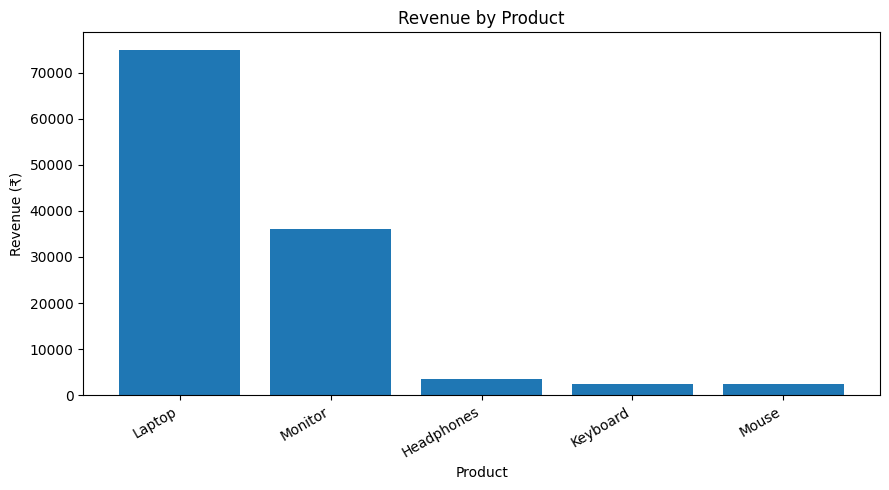

In [0]:
product_chart_pd = (
    spark.table(f"{bronze_schema}.gold_product_sales")
    .select("product_name", "total_revenue")
    .orderBy(F.desc("total_revenue"))
    .toPandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.bar(product_chart_pd["product_name"], product_chart_pd["total_revenue"])
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# 6.6 Incremental MERGE and Delta Lake history

The demo uses overwrite for simplicity, but production pipelines commonly process incremental changes. This section demonstrates a Delta `MERGE INTO` upsert and transaction history.


In [0]:
# MERGE demonstration against the customer Gold mart.
# The staged row is sourced from the latest incremental batch in a real pipeline.
spark.sql(f"""
CREATE OR REPLACE TEMP VIEW staged_customer_updates AS
SELECT customer_id, customer_name, city, total_orders, total_items, total_revenue, average_order_value, last_order_date
FROM {bronze_schema}.gold_customer_sales
WHERE customer_id = 101
""")

spark.sql(f"""
MERGE INTO {bronze_schema}.gold_customer_sales AS target
USING staged_customer_updates AS source
ON target.customer_id = source.customer_id
WHEN MATCHED THEN UPDATE SET *
WHEN NOT MATCHED THEN INSERT *
""")

merge_check = spark.table(f"{bronze_schema}.gold_customer_sales")
assert merge_check.count() == 5
assert merge_check.groupBy("customer_id").count().filter(F.col("count") > 1).count() == 0
print("DELTA MERGE DEMO: PASS")


DELTA MERGE DEMO: PASS


## Delta transaction history

Delta Lake records table operations, versions, timestamps, and operation metrics.


In [0]:
display(
    spark.sql(f"DESCRIBE HISTORY {bronze_schema}.gold_customer_sales")
    .select("version", "timestamp", "operation", "operationMetrics")
)


version,timestamp,operation,operationMetrics
2,2026-08-19T04:44:07.000Z,OPTIMIZE,"Map(numRemovedFiles -> 2, numRemovedBytes -> 5174, p25FileSize -> 2732, numDeletionVectorsRemoved -> 1, minFileSize -> 2732, numAddedFiles -> 1, maxFileSize -> 2732, p75FileSize -> 2732, p50FileSize -> 2732, numAddedBytes -> 2732)"
1,2026-08-19T04:44:05.000Z,MERGE,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 2478, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 1, executionTimeMs -> 6106, materializeSourceTimeMs -> 580, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 3364, numTargetRowsUpdated -> 1, numOutputRows -> 1, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 1, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2060)"
0,2026-08-19T04:43:26.000Z,CREATE OR REPLACE TABLE AS SELECT,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 5, numOutputBytes -> 2696)"


# 7. FINAL END-TO-END RECONCILIATION

This is the final quality gate for the complete project.

We verify:

- Bronze preserved the source counts
- business-key duplicates were explicitly identified and audited
- Silver contains only valid records
- `order_id` is non-null and unique in Silver
- (`order_id`, `product_id`) is unique in Silver order items
- quarantined records are accounted for
- referential integrity is clean
- order-level revenue reconciles to item-level revenue
- Gold reconciles to Silver
- revenue is not duplicated by joins


In [0]:
# Reload everything from Delta tables.

bronze_customers_final = spark.table(f"{bronze_schema}.bronze_customers")
bronze_products_final = spark.table(f"{bronze_schema}.bronze_products")
bronze_orders_final = spark.table(f"{bronze_schema}.bronze_orders")
bronze_items_final = spark.table(f"{bronze_schema}.bronze_order_items")

silver_customers_final = spark.table(f"{bronze_schema}.silver_customers")
silver_products_final = spark.table(f"{bronze_schema}.silver_products")
silver_orders_final = spark.table(f"{bronze_schema}.silver_orders")
silver_items_final = spark.table(f"{bronze_schema}.silver_order_items")

gold_customer_final = spark.table(f"{bronze_schema}.gold_customer_sales")
gold_product_final = spark.table(f"{bronze_schema}.gold_product_sales")
gold_daily_final = spark.table(f"{bronze_schema}.gold_daily_sales")
gold_summary_final = spark.table(f"{bronze_schema}.gold_sales_summary")


In [0]:
# -----------------------------
# Bronze checks
# -----------------------------

assert bronze_customers_final.count() == 6
assert bronze_products_final.count() == 5
assert bronze_orders_final.count() == 9
assert bronze_items_final.count() == 9

# -----------------------------
# Silver checks
# -----------------------------

assert silver_customers_final.count() == 5
assert silver_products_final.count() == 5
assert silver_orders_final.count() == 5
assert silver_items_final.count() == 7

assert silver_orders_final.filter(F.col("order_id").isNull()).count() == 0

assert (
    silver_orders_final
    .groupBy("order_id")
    .count()
    .filter(F.col("count") > 1)
    .count()
    == 0
)

assert (
    silver_items_final
    .groupBy("order_id", "product_id")
    .count()
    .filter(F.col("count") > 1)
    .count()
    == 0
)

# -----------------------------
# Quarantine checks
# -----------------------------

q_orders = spark.table(
    f"{bronze_schema}.quarantine_orders"
)

q_duplicate_customers = spark.table(
    f"{bronze_schema}.quarantine_duplicate_customers"
)

q_duplicate_orders = spark.table(
    f"{bronze_schema}.quarantine_duplicate_orders"
)

q_duplicate_items = spark.table(
    f"{bronze_schema}.quarantine_duplicate_order_items"
)

q_orphan_items = spark.table(
    f"{bronze_schema}.quarantine_orphan_order_items"
)

assert q_orders.count() == 3
assert q_duplicate_customers.count() == 1
assert q_duplicate_orders.count() == 1
assert q_duplicate_items.count() == 1
assert q_orphan_items.count() == 1

q_reconciliation = spark.table(
    f"{bronze_schema}.quarantine_order_reconciliation"
)
assert q_reconciliation.count() == 0

# -----------------------------
# Gold checks
# -----------------------------

assert gold_customer_final.count() == 5
assert gold_customer_final.agg(F.sum("total_orders")).first()[0] == 5
assert gold_customer_final.agg(F.sum("total_items")).first()[0] == 7
assert gold_customer_final.agg(F.sum("total_revenue")).first()[0] == 119400

assert gold_product_final.agg(F.sum("units_sold")).first()[0] == 7
assert gold_product_final.agg(F.sum("total_revenue")).first()[0] == 119400

assert gold_daily_final.agg(F.sum("total_orders")).first()[0] == 5
assert gold_daily_final.agg(F.sum("total_revenue")).first()[0] == 119400

assert gold_summary_final.first()["total_orders"] == 5
assert gold_summary_final.first()["total_revenue"] == 119400

# -----------------------------
# Revenue reconciliation
# -----------------------------

assert silver_orders_final.agg(F.sum("order_amount")).first()[0] == 119400

print("==========================================")
print("FINAL END-TO-END QUALITY GATE: PASS")
print("==========================================")
print("Bronze: source-aligned")
print("Silver: validated, deduplicated, and referentially clean")
print("Gold: reconciled and business-ready")
print("Order revenue = item revenue: 119,400")
print("Reconciliation quarantine rows: 0")
print("==========================================")


FINAL END-TO-END QUALITY GATE: PASS
Bronze: source-aligned
Silver: validated, deduplicated, and referentially clean
Gold: reconciled and business-ready
Order revenue = item revenue: 119,400
Reconciliation quarantine rows: 0


# 8. Final Architecture

```text
                         SOURCE
                           │
             ┌─────────────┼─────────────┐
             │             │             │
         Customers      Products       Orders
                                           │
                                      Order Items
                           │
                           ▼
                    ┌─────────────┐
                    │   BRONZE    │
                    │             │
                    │ Raw Delta   │
                    │ source data │
                    └──────┬──────┘
                           │
                  Standardization
                           │
                 Business-key checks
                           │
              Deterministic deduplication
                           │
                      Validation
                           │
             ┌─────────────┴─────────────┐
             │                           │
             ▼                           ▼
        ┌───────────┐              ┌─────────────┐
        │  SILVER   │              │ QUARANTINE  │
        │           │              │             │
        │ Clean     │              │ Invalid     │
        │ Validated │              │ Duplicates  │
        │ Trusted   │              │ Orphaned    │
        └─────┬─────┘              └─────────────┘
              │
       Revenue reconciliation
              │
       Business aggregation
              │
              ▼
         ┌──────────┐
         │   GOLD   │
         │          │
         │ Customer │
         │ Product  │
         │ Daily    │
         │ Summary  │
         └──────────┘
```

## Key engineering lessons demonstrated

### 1. Bronze is not the cleaning layer

Preserve source data first.

### 2. Business keys matter

`order_id` identifies an order and (`order_id`, `product_id`) identifies an order-item row in this project. Exact-row deduplication alone is not enough when the business grain is defined by keys.

### 3. Deduplication should be deterministic

When multiple records share a business key, define a reproducible winner using explicit ordering columns rather than relying on `dropDuplicates()`.

### 4. Validate identifiers before assigning VALID

A row with a missing `order_id` can never be a valid order, even if its other fields look acceptable.

### 5. Referential integrity matters

An individually valid row can still be unusable if its parent entity does not exist.

### 6. Grain matters

Never aggregate an order-level measure after expanding it to an order-item grain without understanding the duplication risk.

### 7. Revenue assumptions must be explicit

This synthetic project assumes:

```text
order_amount = SUM(quantity × product.price)
```

The assumption is tested at order grain before Gold metrics are produced.

### 8. LEFT JOIN preserves declared Gold grain

`gold_customer_sales` is one row per customer, so the customer dimension remains the driving table and is joined to aggregated sales metrics with a LEFT JOIN.

### 9. Reconciliation matters

A successful Spark job does **not** automatically mean the data is correct.

Always compare important Gold metrics against trusted Silver totals and validate business-rule reconciliations.

---

## Portfolio/blog talking points

This implementation gives you concrete material for:

- **Building a Modern Lakehouse with Medallion Architecture**
- **Data Quality Engineering: Building Reliable Data Pipelines**
- **Business-Key Deduplication and Deterministic Record Selection in PySpark**
- **Understanding Data Grain and Avoiding Double Counting in Spark**
- **Revenue Reconciliation Across Order and Order-Item Grains**
- **PySpark Joins, Aggregations, Delta Lake, and Data Quality Gates**

The project demonstrates practical **Python, SQL, PySpark, Delta Lake, Databricks, data quality, business-key handling, joins, aggregation, reconciliation, and analytical engineering** rather than simply listing those technologies on a resume.
